In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
# from erddapClient import ERDDAP_Griddap
from netCDF4 import Dataset
import cmocean
from mpl_toolkits.basemap import Basemap
from matplotlib import colors
from scipy.stats import linregress
import pandas as pd
import xarray as xr

In [2]:
# Global Ocean Colour (Copernicus-GlobColour), Bio-Geo-Chemical, L4 (monthly and interpolated) from Satellite Observations (Near Real Time)
file_id = Dataset('../../data/chl/chl_1999_2023_day_l3_slope_region_20260313.nc')
chl = file_id.variables["CHL"][:]
time = file_id.variables["time"][:]
lat = file_id.variables["latitude"][:]
lon = file_id.variables["longitude"][:]
file_id.close()

timedelta_vector = (time * np.timedelta64(1, 'D')).astype('timedelta64[ns]')
base_date = np.datetime64('1900-01-01')
date_vector = base_date + timedelta_vector
chl_time = pd.to_datetime(date_vector)

In [3]:
# Filter to <= 2022-12-30
time_mask = chl_time <= '2022-12-30'

chl_crop = chl[time_mask, :, :]
chl_time = chl_time[time_mask]

print(f"Time range: {chl_time[0].date()} to {chl_time[-1].date()}")
print(f"Cropped shape: {chl_crop.shape}")
print(f"Lat window: {lat}")
print(f"Lon window: {lon}")

Time range: 1999-01-01 to 2022-12-30
Cropped shape: (8765, 48, 48)
Lat window: [23.020832 23.062498 23.104164 23.145832 23.187498 23.229164 23.270832
 23.312498 23.354164 23.395832 23.437498 23.479164 23.520832 23.562498
 23.604164 23.645832 23.687498 23.729164 23.770832 23.812498 23.854164
 23.895832 23.937498 23.979164 24.020832 24.062498 24.104164 24.145832
 24.187498 24.229164 24.270832 24.312498 24.354164 24.395832 24.437498
 24.479164 24.520832 24.562498 24.604164 24.645832 24.687498 24.729164
 24.770832 24.812498 24.854164 24.895832 24.937498 24.979164]
Lon window: [-153.97917 -153.9375  -153.89583 -153.85417 -153.8125  -153.77083
 -153.72917 -153.6875  -153.64583 -153.60417 -153.5625  -153.52083
 -153.47917 -153.4375  -153.39583 -153.35417 -153.3125  -153.27083
 -153.22917 -153.1875  -153.14583 -153.10417 -153.0625  -153.02083
 -152.97917 -152.9375  -152.89583 -152.85417 -152.8125  -152.77083
 -152.72917 -152.6875  -152.64583 -152.60417 -152.5625  -152.52083
 -152.47917 -152.43

In [4]:
# Build an xarray DataArray with the time coordinate
chl_xa = xr.DataArray(
    chl_crop,
    dims=['time', 'lat', 'lon'],
    coords={
        'time': chl_time,
        'lat': lat,
        'lon': lon
    }
)

# Compute median climatology for each day of year (1–366)
# chl_clim = chl_xa.groupby('time.dayofyear').median(dim='time')
chl_clim = chl_xa.groupby('time.month').median(dim='time', skipna=True)
chl_anom = chl_xa.groupby('time.month') - chl_clim

In [5]:
summer_months = [6, 7, 8, 9, 10]
chl_anom_summer = chl_anom.sel(time=chl_anom['time.month'].isin(summer_months))

print(f"Summer subset shape: {chl_anom_summer.shape}")
print(f"Date range: {chl_anom_summer.time.values[0]} to {chl_anom_summer.time.values[-1]}")

Summer subset shape: (3672, 48, 48)
Date range: 1999-06-01T00:00:00.000000000 to 2022-10-31T00:00:00.000000000


In [6]:
from scipy import stats

# Spatial mean across the 3x3 box
chl_anom_ts = chl_anom.mean(dim=['lat', 'lon'], skipna=True)

# Convert time to numeric (days since start)
x_days = (chl_time - chl_time[0]).days.values
y = chl_anom_ts.values

# Mask out NaNs for regression
mask = ~np.isnan(y)
slope, intercept, r_value, p_value, std_err = stats.linregress(x_days[mask], y[mask])

# Regression line
y_fit = slope * x_days + intercept

# Convert slope to per year
slope_per_year = slope * 365.25

print(f"Slope: {slope_per_year:.6f} per year")
print(f"R²: {r_value**2:.4f}")
print(f"p-value: {p_value:.2e}")

Slope: 0.000186 per year
R²: 0.0069
p-value: 1.15e-13


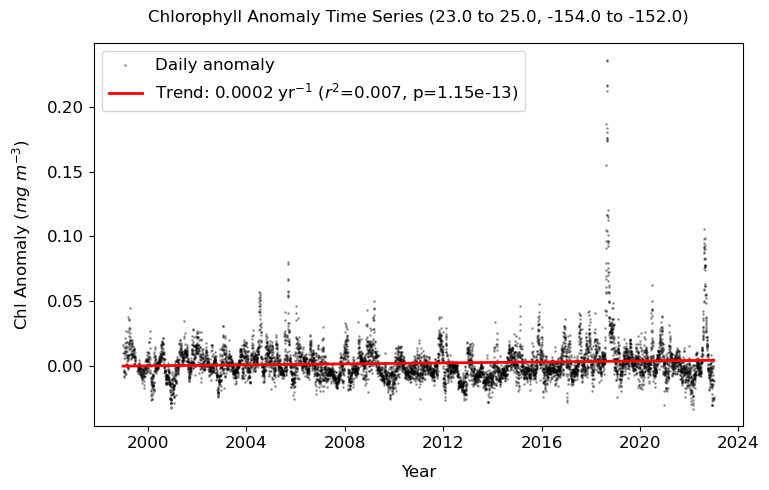

In [7]:
# Plot
fig, ax = plt.subplots(figsize=(7.8, 5))
# ax.plot(chl_time, chl_anom_ts, linewidth=0.5, color='black', alpha=0.7, label='Daily anomaly')
ax.scatter(chl_time, chl_anom_ts, s=1, color='black', alpha=0.3, label='Daily anomaly')
ax.plot(chl_time, y_fit, linewidth=2, color='red', 
        label=f'Trend: {slope_per_year:.4f} yr$^{{-1}}$ ($r^2$={r_value**2:.3f}, p={p_value:.2e})')
# ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)

ax.set_xlabel('Year', fontsize=12, fontweight='normal', labelpad=10)
ax.set_ylabel('Chl Anomaly ($mg$ $m^{-3}$)', fontsize=12, fontweight='normal', labelpad=10)
ax.set_title('Chlorophyll Anomaly Time Series (23.0 to 25.0, -154.0 to -152.0)', fontsize=12, pad=15)
ax.legend(fontsize=12, loc='best')
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
fig.savefig('../../figures/chl_anomaly_trend_20260313.png', dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig('../../figures/chl_anomaly_trend_20260313.pdf', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

Slope: 0.000515 per year
R²: 0.0324
p-value: 3.90e-26


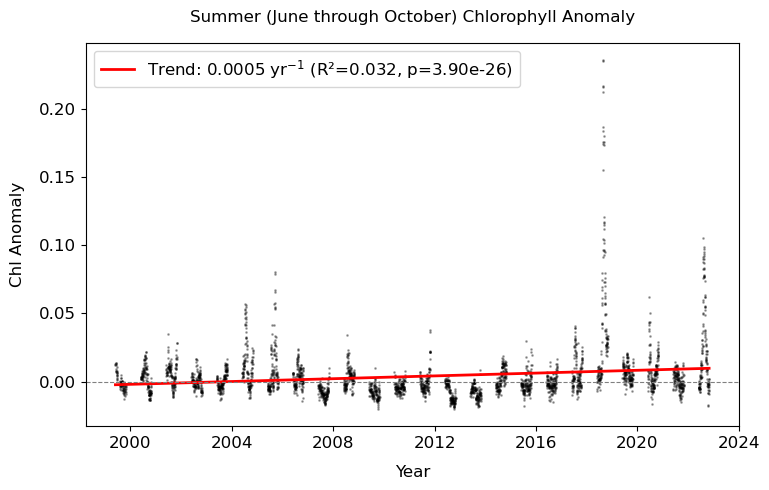

In [8]:
# Subset summer months
summer_months = [6, 7, 8, 9, 10]
chl_anom_summer = chl_anom.sel(time=chl_anom['time.month'].isin(summer_months))

# Spatial mean
chl_anom_summer_ts = chl_anom_summer.mean(dim=['lat', 'lon'], skipna=True)
chl_time_summer = pd.to_datetime(chl_anom_summer.time.values)

# Regression
x_days = (chl_time_summer - chl_time_summer[0]).days.values
y = chl_anom_summer_ts.values
mask = ~np.isnan(y)
slope, intercept, r_value, p_value, std_err = stats.linregress(x_days[mask], y[mask])
y_fit = slope * x_days + intercept
slope_per_year = slope * 365.25

print(f"Slope: {slope_per_year:.6f} per year")
print(f"R²: {r_value**2:.4f}")
print(f"p-value: {p_value:.2e}")

# Plot
fig, ax = plt.subplots(figsize=(7.8, 5))
ax.scatter(chl_time_summer, chl_anom_summer_ts, s=1, color='black', alpha=0.3)
ax.plot(chl_time_summer, y_fit, linewidth=2, color='red', label=f'Trend: {slope_per_year:.4f} yr$^{{-1}}$ (R²={r_value**2:.3f}, p={p_value:.2e})')
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)

ax.set_xlabel('Year', fontsize=12, fontweight='normal', labelpad=10)
ax.set_ylabel('Chl Anomaly', fontsize=12, fontweight='normal', labelpad=10)
ax.set_title('Summer (June through October) Chlorophyll Anomaly', fontsize=12, pad=15)
ax.legend(fontsize=12, loc='best')
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
fig.savefig('../../figures/chl_anomaly_summer_trend_20260313.png', dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig('../../figures/chl_anomaly_summer_trend_20260313.pdf', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()